# 07 — Comparación final, conclusiones y caminos futuros

**TP Final · Aprendizaje de Máquina I (CEIA-FIUBA)** · Jaime Pinzón (a2629)

Este notebook consolida los resultados de todos los modelos entrenados (notebooks 02–06) y cierra el trabajo con las conclusiones. Todos los modelos comparten exactamente los mismos datos (parquets de `data/processed/`), el mismo preprocesador (`build_preprocessor`, con escalado solo donde el modelo lo exige), la misma CV (KFold 5, seed 42, solo sobre train) y la misma evaluación final: **una única pasada sobre el test completo de 20.354 encuentros, que conserva las estadías largas que el train filtró** — el escenario honesto de producción.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from src.evaluacion import RUTA_METRICAS

tabla = pd.read_csv(RUTA_METRICAS).sort_values("mae").reset_index(drop=True)
BASELINE = tabla.loc[tabla["modelo"] == "baseline_media", "mae"].iloc[0]

vista = tabla[["modelo", "mae", "rmse", "r2", "tiempo_s", "pred_test_s"]].copy()
vista.columns = ["modelo", "MAE (dias)", "RMSE", "R2", "refit (s)", "pred. test (s)"]
vista["vs baseline"] = (vista["MAE (dias)"] - BASELINE).round(3)
vista.round(4)

,modelo,MAE (dias),RMSE,R2,refit (s),pred. test (s),vs baseline
0,xgboost,1.7463,2.4176,0.3440,11.21,0.08,-0.534
1,svr_rbf,1.7687,2.4425,0.3304,107.99,83.07,-0.512
2,random_forest,1.7980,2.3994,0.3539,9.96,0.35,-0.483
3,knn,1.8341,2.4731,0.3136,0.10,7.40,-0.446
4,svr_lineal,1.8343,2.5168,0.2891,0.24,0.02,-0.446
5,arbol_podado,1.8585,2.4829,0.3081,5.77,0.02,-0.422
6,regresion_lineal,1.8616,2.4666,0.3171,0.08,0.02,-0.419
7,baseline_media,2.2805,3.0009,-0.0107,0.09,0.01,0.000
8,baseline_mediana,2.2929,3.2952,-0.2187,0.05,0.01,0.012


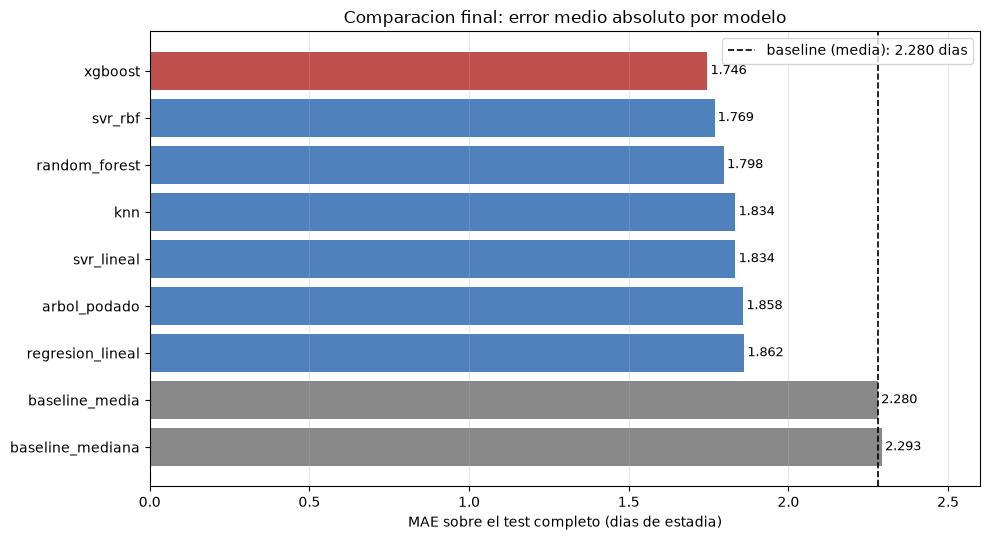

In [2]:
fig, ax = plt.subplots(figsize=(10, 5.5))
orden = tabla.sort_values("mae", ascending=False)
colores = ["#888888" if m.startswith("baseline") else
           ("#c0504d" if m == orden.iloc[-1]["modelo"] else "#4f81bd")
           for _, m in zip(orden.index, orden["modelo"])]
ax.barh(orden["modelo"], orden["mae"], color=colores)
ax.axvline(BASELINE, color="black", linestyle="--", linewidth=1.2,
           label=f"baseline (media): {BASELINE:.3f} dias")
for i, (_, fila) in enumerate(orden.iterrows()):
    ax.text(fila["mae"] + 0.01, i, f"{fila['mae']:.3f}", va="center", fontsize=9)
ax.set_xlabel("MAE sobre el test completo (dias de estadia)")
ax.set_title("Comparacion final: error medio absoluto por modelo")
ax.legend(); ax.grid(axis="x", alpha=0.3)
ax.set_xlim(0, 2.6)
plt.tight_layout(); plt.show()

## Lectura global

**La brecha que importa está contra el baseline, no entre modelos.** El mejor modelo (XGBoost, MAE 1,746) le recorta **0,53 días (−23,4%)** a la política ingenua de predecir el promedio (2,280). Pero entre los cinco modelos no lineales — XGBoost 1,746, SVR-RBF 1,769, Random Forest 1,798, KNN 1,834, árbol podado 1,858 — la distancia total es de apenas **0,11 días**: una vez capturada la no linealidad principal, la elección de familia mueve el resultado mucho menos que haberla capturado. Para la gestión hospitalaria: cualquiera de estos modelos planifica camas sustancialmente mejor que el promedio histórico; la diferencia entre ellos es fina y se decide por costo operativo e interpretabilidad.

**El techo de predictibilidad es un hallazgo, no un fracaso.** Ningún modelo supera R² ≈ 0,33–0,35: dos tercios de la varianza de la estadía **no son explicables con estas 8 variables de admisión**. Es coherente con la naturaleza del problema: la duración de una internación depende de eventos posteriores al ingreso (evolución clínica, complicaciones, disponibilidad de altas, factores sociales del alta) que ninguna variable de admisión contiene. Contribuyen además dos factores documentados en los notebooks 01–02: el target es discreto y fuertemente asimétrico (skew ≈ 1), y el test conserva las estadías de 13–14 días que el filtro IQR removió del train (shift documentado en el NB02) — los modelos nunca vieron ejemplos de la cola que sí se les evalúa, deliberadamente, porque en producción esa cola existe.

**Costo computacional: XGBoost domina en toda la frontera.** Gana en MAE con ~12 s de refit y ~0,1 s de predicción sobre 20k pacientes. Su rival más cercano (SVR-RBF, +0,022 días de MAE) paga 110 s de entrenamiento y **86 s por cada pasada de predicción** — inviable para re-puntuar la cartera de camas varias veces al día. Random Forest queda como alternativa sólida: mejor RMSE (2,399) y mejor R² (0,354) del cuadro, señal de que el promediado de bagging controla mejor los errores grandes, mientras XGBoost — entrenado con `reg:absoluteerror` (decisión D4) — optimiza exactamente el MAE, y se nota: cada uno lidera la métrica que su función de pérdida favorece.

**La señal de negocio no depende del modelo.** La permutation importance sobre el test coincide entre los dos ensambles — mecanismos opuestos, mismo ranking: `num_medications` (0,35/0,33 días), `num_lab_procedures` (0,19/0,16) y `diag_1` (0,14/0,13) encabezan tanto en XGBoost como en Random Forest (NB06). La intensidad de tratamiento como predictor dominante de la estadía es una propiedad de los datos, no un artefacto de la familia elegida.

**Interpretabilidad como criterio de desempate:** si el hospital exigiera reglas auditables, el árbol podado (MAE 1,858, apenas 0,11 días peor que XGBoost) ofrece 326 hojas legibles; y el feature importance del NB06 mostró que la señal dominante — intensidad de medicación y laboratorio — está disponible desde las primeras horas de la admisión.

## Conclusiones (parte 2)

### Respuesta a la pregunta de investigación

*¿Cuántos días permanecerá internado un paciente diabético, estimado al momento de su ingreso?* El mejor modelo (XGBoost sobre 8 variables de admisión) responde con un **error medio de 1,75 días**, contra los 2,28 días de la política ingenua de asumir la estadía promedio: **0,53 días menos de error por paciente (−23,4%)**. En términos operativos: para un hospital con 10.000 admisiones diabéticas anuales, esa mejora equivale a ~5.300 días-cama anuales de error de planificación eliminados — capacidad real para programar ocupación, quirófanos y dotación de enfermería. El modelo además corre con insumos disponibles en las primeras horas de la admisión (medicaciones iniciadas, laboratorio solicitado, diagnóstico primario provisional, edad), puntúa 20.000 pacientes en una décima de segundo y se re-entrena en 12 segundos: es desplegable como herramienta de gestión diaria.

### Límites honestos

1. **Techo de predictibilidad**: R² ≈ 0,33–0,35 en todos los modelos. Dos tercios de la varianza de la estadía dependen de eventos posteriores al ingreso (evolución clínica, complicaciones, gestión del alta) que ninguna variable de admisión puede contener. El MAE de 1,75 días es probablemente cercano al límite alcanzable con este set de features — mejorarlo exige *más información*, no más modelo.
2. **Hiperparámetros del SVR-RBF buscados en submuestra** (16k de 53,7k) por costo O(n²), con refit sin re-búsqueda: su MAE de 1,769 es un piso conservador de la familia (limitación documentada en el NB04).
3. **Shift train filtrado / test sin filtrar**: el filtro IQR removió del train las estadías de 13–14 días que el test conserva (450 casos). Es una decisión deliberada — en producción los pacientes extremos existen — pero implica que los modelos se evalúan sobre una cola que no vieron, y explica parte del techo anterior (documentado con la evidencia media-vs-mediana en el NB02).

### Caminos futuros

- **Re-búsqueda de hiperparámetros del SVR-RBF a escala completa** (levantar el límite 2): es el rival más cercano del ganador y su búsqueda quedó acotada por presupuesto.
- **Reformulación como clasificación de reingreso <30 días** — el uso clásico de este dataset (Strack et al., 2014): mismo pipeline de datos, target `readmitted`, y las métricas pasarían a precision/recall sobre la clase minoritaria.
- **Calibración de probabilidades** (clase 6 de la materia) si se adopta la reformulación anterior: en decisiones clínicas, la probabilidad bien calibrada vale tanto como la discriminación.
- **Clustering de perfiles de pacientes** (clase 7): segmentar la población diabética (K-Means / GMM sobre las mismas features) para descubrir subgrupos con dinámicas de estadía distintas y modelos específicos por segmento.
- **Anexo PCA para KNN/SVR** (tarea 3.5 del plan, no ejecutada por regla de alcance): cuantificar el intercambio performance↔velocidad con las 11 componentes que el análisis de AdD dejó listas.
- **Features de evolución temprana**: si el hospital captura datos de las primeras 24 h (signos vitales, interconsultas), incorporarlos es la vía más prometedora para romper el techo de R².

### Reflexión final

El trabajo confirma la premisa metodológica de la materia: el valor no estuvo en probar muchos modelos sino en la **disciplina alrededor** de ellos — un baseline honesto que fijó el piso, un preprocesamiento congelado e idéntico para todas las familias, validación cruzada sin fugas (el TargetEncoder re-fiteado por fold fue el punto más delicado), un test intocado hasta el final, y métricas traducidas al lenguaje del negocio. La brecha de 0,11 días entre cinco familias distintas — contra 0,53 días de brecha con el baseline — es la ilustración más clara: **elegir bien el problema y proteger la evaluación importa más que la elección fina del algoritmo.**